# 003 — Results

Paper reproductions and new derivations.

## 3.1 Literature matches

Each derivation reproduces the published equations literally.

| Model | Reference | Result |
|---|---|---|
| SWE / SME L=0,1,2 | Kowalski & Torrilhon 2019 eqs (4.13)/(4.14)/(4.17) | ✓ all coefficients match |
| Multilayer SWE, $N$=2,3,5,7 | Aguillon, Hörnschemeyer, Sainte-Marie 2026 eq (5) | ✓ per-layer continuity, x-mom, tracer |
| VAM (1, 2) | Escalante, Morales de Luna, Cantero-Chinchilla, Castro-Orgaz 2024 eq (4)–(5) | ✓ eq (4) rows 1, 2, 3 + eq (5) constraints I_1, I_2, w_2 closure |
| VAM (1, 2) Poisson | same paper, eq (15) | ✓ both constraints strictly linear in $(p_0, p_1, \partial_x p_\cdot, \partial_{xx} p_\cdot)$ |
| VAM (1, 2) dispersion | same paper, eq (8) | ✓ $C^2/(gH) = 12(H^2k^2 + 12)/(H^4k^4 + 60 H^2k^2 + 144)$ |

## 3.2 New result: VAM (2, 3) dispersion

Same Galerkin pipeline at one degree higher.  All three components
(continuity j=1..3, KBC bottom, surface BC) generate themselves
automatically — no model logic changes.

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd(), "..", "tutorials", "vam"))
import sympy as sp
from vam_builder import build_vam_pde_system, h, b
from zoomy_core.analysis import linearise, plane_wave_dispersion

H = sp.Symbol("H", positive=True)
g = sp.Symbol("g", positive=True)

results = {}
for (M, N) in [(1, 2), (2, 3)]:
    print(f"=== VAM (M={M}, N={N}) dispersion ===")
    sys_vam, *_ = build_vam_pde_system(M, N)
    sys_vam = sys_vam.with_substitutions({b: -H})
    base = {f: sp.S.Zero for f in sys_vam.fields}
    base[sys_vam.fields[0]] = H
    sys_lin = linearise(sys_vam, base)
    k = sp.Symbol("k", real=True, nonzero=True)
    omega = sp.Symbol("omega", real=True)
    disp = plane_wave_dispersion(sys_lin, k=k, omega=omega, simplify=True,
                                  factor_in_target=True)
    pvs = [sp.simplify(s/k) for s in disp["solutions"]]
    propagating = [pv for pv in pvs if sp.simplify(pv) != 0]
    abs_pvs = sorted({sp.simplify(pv**2) for pv in propagating}, key=lambda e: str(e))
    for c2 in abs_pvs:
        c2_over_gH = sp.simplify(c2 / (g * H))
        print(f"  C²/(gH) = {c2_over_gH}")
        results[(M, N)] = c2_over_gH
    print()

=== VAM (M=1, N=2) dispersion ===


  C²/(gH) = 12*(H**2*k**2 + 12)/(H**4*k**4 + 60*H**2*k**2 + 144)

=== VAM (M=2, N=3) dispersion ===


  C²/(gH) = 24*(H**4*k**4 + 70*H**2*k**2 + 600)/(H**6*k**6 + 264*H**4*k**4 + 6480*H**2*k**2 + 14400)



Both formulas are **Padé approximants** of the exact dispersion relation
for a free-surface 2D incompressible flow:
$$\frac{C^2}{gH} = \frac{\tanh(kH)}{kH}\;\;\text{(Airy theory)}.$$

* VAM (1, 2): degree-4 rational in $(kH)^2$ (3 ω solutions).
* VAM (2, 3): degree-6 rational in $(kH)^2$ (next Padé level).

Plot:

Text(0.5, 1.0, 'VAM dispersion vs Airy theory')

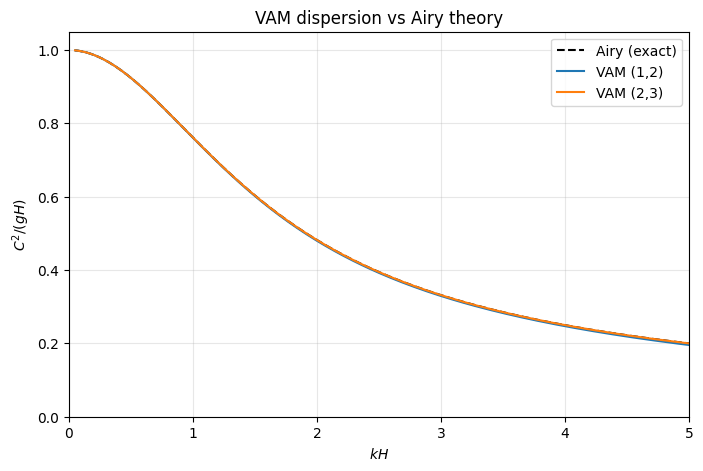

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
k_arr = np.linspace(0.05, 5, 200)
H_val = 1.0
ax.plot(k_arr, np.tanh(k_arr * H_val) / (k_arr * H_val), "k--", label="Airy (exact)")
for (M, N), c2_expr in results.items():
    f = sp.lambdify((sp.Symbol("k", real=True, nonzero=True), H), c2_expr, "numpy")
    ax.plot(k_arr, f(k_arr, H_val), label=f"VAM ({M},{N})")
ax.set_xlim(0, 5); ax.set_ylim(0, 1.05)
ax.set_xlabel(r"$kH$"); ax.set_ylabel(r"$C^2/(gH)$")
ax.legend(); ax.grid(alpha=0.3)
ax.set_title("VAM dispersion vs Airy theory")

## 3.3 SME hyperbolicity at L=2

At low velocity moments, all states are hyperbolic.  At higher
moments the system loses hyperbolicity in 4 diagonal strips of the
$(\alpha_1/\sqrt{gH}, \alpha_2/\sqrt{gH})$ plane (Koellermeier &
Torrilhon analysis).  We recover this here via
`plot_hyperbolic_region_2d`.

Text(0, 0.5, '$\\alpha_2 / \\sqrt{gH}$')

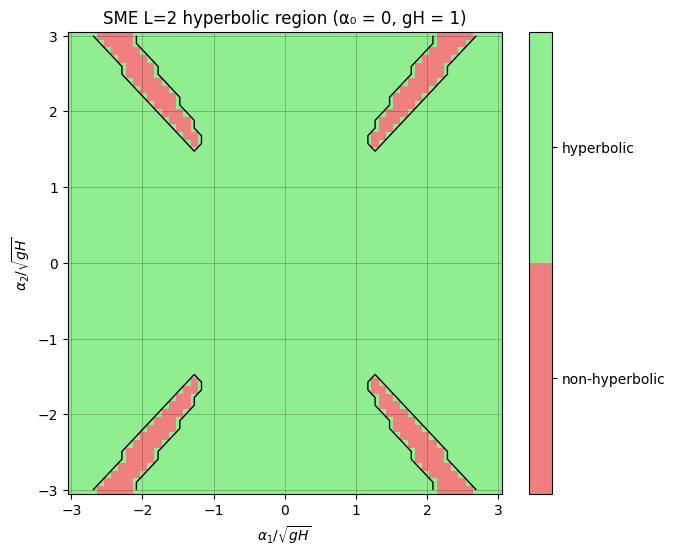

In [3]:
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd(), "..", "tutorials", "sme"))
from sme_builder import build_sme_pde_system, g as g_sme
from zoomy_core.analysis import (
    linearise as _lin, extract_quasilinear_pencil as _pencil,
    plot_hyperbolic_region_2d,
)

sys_sme, h_field, u_coeffs = build_sme_pde_system(2)
H_bar = sp.Symbol("H_bar", positive=True)
U_0 = sp.Symbol("U_0", real=True)
U_1 = sp.Symbol("U_1", real=True)
U_2 = sp.Symbol("U_2", real=True)
sys_lin = _lin(sys_sme, {h_field: H_bar, u_coeffs[0]: U_0,
                          u_coeffs[1]: U_1, u_coeffs[2]: U_2})
M_t, M_xa, _ = _pencil(sys_lin)
M_x = M_xa[0]
fig, ax = plt.subplots(figsize=(7, 6))
plot_hyperbolic_region_2d(
    M_x, M_t,
    axis_a=(U_1, -3.0, 3.0),
    axis_b=(U_2, -3.0, 3.0),
    fixed_subs={g_sme: 1.0, H_bar: 1.0, U_0: 0.0},
    n_a=60, n_b=60, ax=ax,
    title="SME L=2 hyperbolic region (α₀ = 0, gH = 1)",
)
ax.set_xlabel(r"$\alpha_1 / \sqrt{gH}$")
ax.set_ylabel(r"$\alpha_2 / \sqrt{gH}$")

## 3.4 3D generalisation

The same builders work at `dimension=3` — verified via direct
smoke tests for SME and ML-SWE in `tutorials/sme/sme_3d_smoke_test.py`
and `tutorials/multilayer/mlswe_3d_smoke_test.py`.  Cross-axis
advection terms (e.g. $\alpha_{y,0}\,\partial_y\,\alpha_{x,0}\,h$ in
the $x$-momentum projection) emerge naturally; no internal
modifications to the framework needed.